<a href="https://colab.research.google.com/github/maximussy26/Python-coursework-questions-1-3/blob/main/python_coursework_q7_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import scipy.stats as stats

In [ ]:
df = pd.read_csv('ncbirths.csv')

question 7a

In [ ]:
df['premature'] = (df['weeks'] < 37).astype(int)

In [ ]:
q7_data = df[['habit', 'premature']].dropna()

In [ ]:
contingency = pd.crosstab(q7_data['habit'], q7_data['premature'],
                          colnames=['premature (0=No, 1=Yes)'])



In [ ]:
print(contingency)

premature (0=No, 1=Yes)    0    1
habit                            
nonsmoker                740  133
smoker                   107   19


In [ ]:
prop_table = pd.crosstab(q7_data['habit'], q7_data['premature'],
                         normalize='index').round(4)


In [ ]:
print(prop_table)

premature       0       1
habit                    
nonsmoker  0.8477  0.1523
smoker     0.8492  0.1508


In [ ]:
smoker_data    = q7_data[q7_data['habit'] == 'smoker']
nonsmoker_data = q7_data[q7_data['habit'] == 'nonsmoker']

In [ ]:
n_s  = len(smoker_data)
n_ns = len(nonsmoker_data)
p_s  = smoker_data['premature'].mean()
p_ns = nonsmoker_data['premature'].mean()

In [ ]:
print(f"\nSmokers:     n = {n_s},  proportion premature = {p_s:.4f}")
print(f"Nonsmokers:  n = {n_ns}, proportion premature = {p_ns:.4f}")


Smokers:     n = 126,  proportion premature = 0.1508
Nonsmokers:  n = 873, proportion premature = 0.1523


question 7b

In [ ]:
diff = p_s - p_ns

In [ ]:
se_diff = np.sqrt((p_s * (1 - p_s) / n_s) + (p_ns * (1 - p_ns) / n_ns))

In [ ]:
z_star = stats.norm.ppf(0.975)

In [ ]:
lower = diff - z_star * se_diff
upper = diff + z_star * se_diff

In [ ]:
print(f"\nPoint estimate (p_smoker - p_nonsmoker): {diff:.4f}")
print(f"Standard error:                          {se_diff:.4f}")
print(f"z* (95% CI):                             {z_star:.4f}")
print(f"\n95% Confidence Interval: ({lower:.4f}, {upper:.4f})")


Point estimate (p_smoker - p_nonsmoker): -0.0016
Standard error:                          0.0341
z* (95% CI):                             1.9600

95% Confidence Interval: (-0.0684, 0.0653)


interpretation is that we are 95% confident the difference in the proportion of premature births lies between  f"{lower:.4f} and {upper:.4f}. since the interval is above zero, this suggests that smokers have a higher proportion of premature births than nonsmokers

question 7c

In [ ]:
p_pool = (smoker_data['premature'].sum() + nonsmoker_data['premature'].sum()) / (n_s + n_ns)

In [ ]:
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_s + 1/n_ns))

In [ ]:
z_stat = diff / se_pool

In [ ]:
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

In [ ]:
print(f"\nPooled proportion:   {p_pool:.4f}")
print(f"Standard error:      {se_pool:.4f}")
print(f"Test statistic (z):  {z_stat:.4f}")
print(f"p-value (two-sided): {p_value:.4f}")


Pooled proportion:   0.1522
Standard error:      0.0342
Test statistic (z):  -0.0454
p-value (two-sided): 0.9638


since p_value > alpha, there is insufficient evidence to conclude that the proportion of premature births differs between smokers and nonsmokers

question 8a

In [ ]:
q8_data = df[['habit', 'weight']].dropna()

In [ ]:
summary = q8_data.groupby('habit')['weight'].agg(
    n='count',
    mean='mean',
    std='std'
).round(4)

In [ ]:
print(summary.to_string())

             n    mean     std
habit                         
nonsmoker  873  7.1443  1.5187
smoker     126  6.8287  1.3862


question 8b

conditions:

- independence:
dataset is a random sample of 1000 births so is independent
events and the 2 groups (smokers and nonsmokers) are seperate
 - so independence is satisfied

- normality:
both groups havea larger population than 30, so even if the weight is skewed, the CLT ensures the sampling of the mean is rouhgly normal.
 - so normality is mostly satisifed

- no extreme outliers:
the data is a real birth-weight sample, so extreme values are possible but the large sample reduces their effect
 - so no extreme outliers is mostly satisfied


question 8c

In [ ]:
smoker_wt    = q8_data[q8_data['habit'] == 'smoker']['weight']
nonsmoker_wt = q8_data[q8_data['habit'] == 'nonsmoker']['weight']

In [ ]:
t_stat, p_val = stats.ttest_ind(smoker_wt, nonsmoker_wt, equal_var=False)

In [ ]:
n1, s1 = len(smoker_wt),    smoker_wt.std()
n2, s2 = len(nonsmoker_wt), nonsmoker_wt.std()
df_welch = (s1**2/n1 + s2**2/n2)**2 / (
    (s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1)
)

In [ ]:
print(f"\nTest statistic (t):  {t_stat:.4f}")
print(f"Degrees of freedom:  {df_welch:.2f}")
print(f"p-value (two-sided): {p_val:.4f}")


Test statistic (t):  -2.3590
Degrees of freedom:  171.32
p-value (two-sided): 0.0195


Conclusion: Since p-value (0.0195) < alpha (0.05), we reject H0. There is sufficient evidence at the 5% significance level to conclude that mean birth weight differs between babies born to smokers and non-smokers. with smokers' babies tending to weigh less.

question 9a

In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
import scipy.stats

In [ ]:
dfm = pd.read_csv('mariokart.csv')

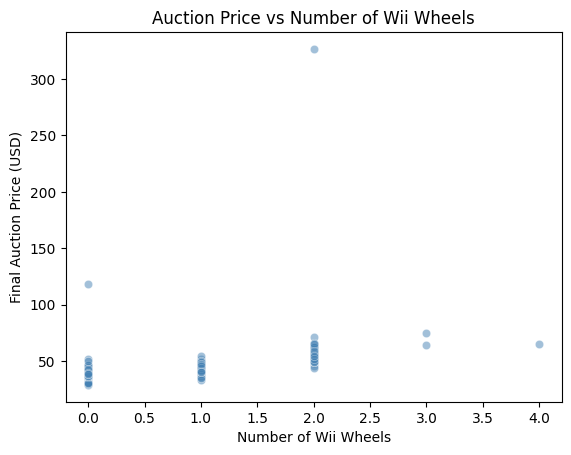

In [ ]:
sns.scatterplot(data=dfm, x="wheels", y="total_pr", alpha=0.5, color="steelblue")
plt.xlabel("Number of Wii Wheels")
plt.ylabel("Final Auction Price (USD)")
plt.title("Auction Price vs Number of Wii Wheels")
plt.show()

description of relationship:

positive, meaning listings with more wheels tend to sell for higher prices
mostly linear, but there is one outlier which distorts the picture
there is a spread of prices at each number of wheels, suggesting that there is something other than number of wheels impacting the auction price

question 9b

In [ ]:
model = smf.ols("total_pr ~ wheels", data=dfm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               total_pr   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     17.23
Date:                Sat, 16 May 2026   Prob (F-statistic):           5.70e-05
Time:                        18:24:34   Log-Likelihood:                -658.35
No. Observations:                 143   AIC:                             1321.
Df Residuals:                     141   BIC:                             1327.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.4052      3.433     11.188      0.0

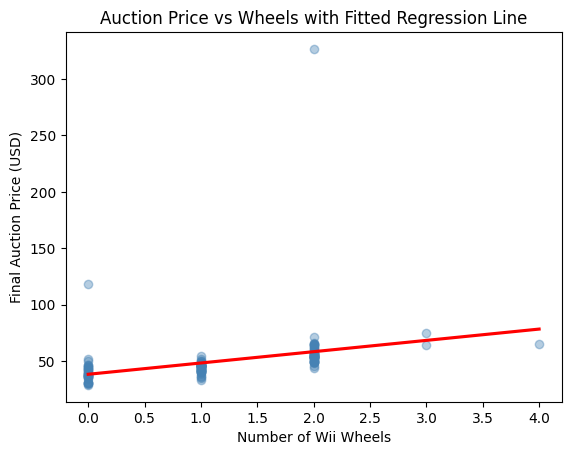

In [ ]:
sns.regplot(data=dfm, x="wheels", y="total_pr", ci=None,
            scatter_kws={"alpha": 0.4, "color": "steelblue"},
            line_kws={"color": "red"})
plt.xlabel("Number of Wii Wheels")
plt.ylabel("Final Auction Price (USD)")
plt.title("Auction Price vs Wheels with Fitted Regression Line")
plt.show()

regression equation:
price = 38.41 + 10 x wheels

 - for each additional wheel included, the predicted final auction price increases by $10 on average, and the y-intercept is 38.41

question 9c

In [ ]:
print(f"R-squared: {model.rsquared:.4f}")

R-squared: 0.1089


interpretation:

wheels explains only about 10.89% of the variation in final auction prices. even though the relationship is statistically significant, the number of wheels isn't strong enough to base a prediction of final auction price from. there are likely many other factors involved

question 9d

In [ ]:
dfm["predicted"] = model.fittedvalues
dfm["residual"]  = model.resid

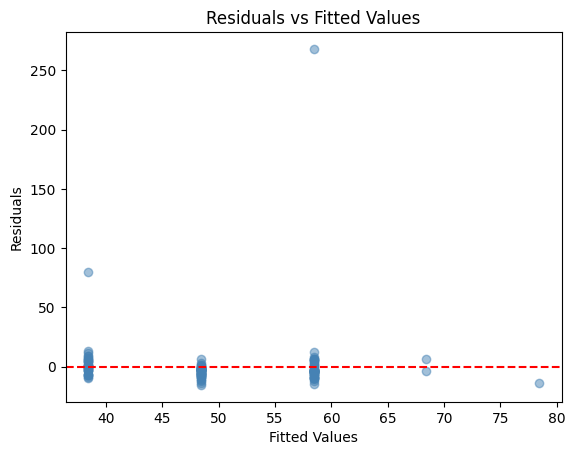

In [ ]:
plt.scatter(dfm["predicted"], dfm["residual"], alpha=0.5, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values"); plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values"); plt.show()

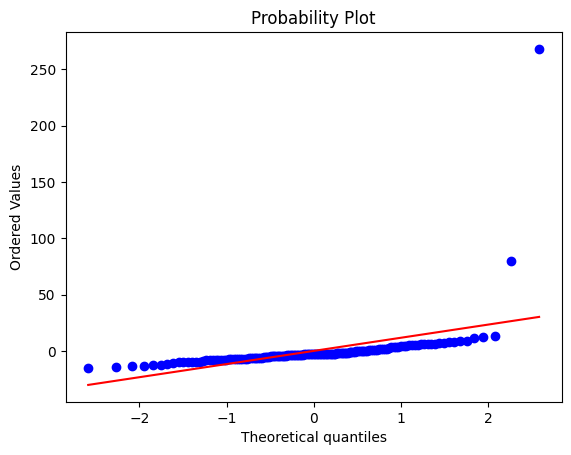

In [ ]:
scipy.stats.probplot(dfm["residual"], dist="norm", plot=plt); plt.show()

linearity:
residuals sactter around 0 without a curve, so linearity is conserved

constant variance:
the residuals are tight for low predicted prices, but go to massive values for high predicted prices. this means that the models errors are much bigger for expensive listings than cheap ones, so constant variance is not conserved

normality:
the q-q plot shows the points going off the diagonal line at the top end, one sold for 326 while everything else was under 80, this pulls the residuals away from a normal distribution.
so normality is violated

the model technically works but the violated assumptions mean the standard errors and p-values arent fully trustworthy.

question 10a

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
model_multi = smf.ols("total_pr ~ C(cond) + C(stock_photo) + duration + wheels",
                       data=dfm).fit()

In [ ]:
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:               total_pr   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     4.860
Date:                Sat, 16 May 2026   Prob (F-statistic):            0.00107
Time:                        18:24:47   Log-Likelihood:                -657.17
No. Observations:                 143   AIC:                             1324.
Df Residuals:                     138   BIC:                             1339.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                43.52

estimated regression equation:

price = 43.52 - (2.58 x used) - (6.75 x stock_photo=yes) + (0.38 x duration) + (9.95 x wheels)

if used, value is 1
if it has a stock photo, value is 1



question 10b

interpereting cond and wheels:

cond(used vs new) - holding all other variables constant, used listings are predicted to sell for $2.58 less than new ones. however the p-value is 0.622, which means the findings are not statistically significant

wheels - holding all other variables constant, each additional wii wheel in the listing is predicted to raise the final price by $9.95. the p-value is <0.001 which is very significant.

comparison:

in the simple model, the wheels coefficient was 10.01, and in the multiple model it is 9.95, which is almost the same. this means that after accounting for all other variables the effect of wheels on the price is basically the same.

question 10c

In [ ]:
m1 = smf.ols("total_pr ~ wheels", data=dfm).fit()
m2 = smf.ols("total_pr ~ C(cond) + C(stock_photo) + duration + wheels", data=dfm).fit()
m3 = smf.ols("total_pr ~ C(cond) + wheels", data=dfm).fit()
m4 = smf.ols("total_pr ~ C(cond) + C(stock_photo) + wheels", data=dfm).fit()

In [ ]:
for name, m in [("M1 (wheels only)", m1), ("M2 (all 4 predictors)", m2),
                ("M3 (cond+wheels)", m3), ("M4 (cond+stock_photo+wheels)", m4)]:
    print(f"{name}: R²={m.rsquared:.4f}, Adj R²={m.rsquared_adj:.4f}, AIC={m.aic:.1f}")

M1 (wheels only): R²=0.1089, Adj R²=0.1026, AIC=1320.7
M2 (all 4 predictors): R²=0.1235, Adj R²=0.0981, AIC=1324.3
M3 (cond+wheels): R²=0.1091, Adj R²=0.0964, AIC=1322.7
M4 (cond+stock_photo+wheels): R²=0.1224, Adj R²=0.1035, AIC=1322.5


using adjusted r^2 for each model, m4 has the highest r^2 and a low AIC (which is the same as r^2 in terms of judging how good a model is). also, m2's r^2 is lower than m1's meaning duration adds noise rather than signal, meaning adding more random variations which add randomness to the model, making it more unreliable.
the best model is m4, since adding duration just hurts r^2, as it adds nothing more than what wheels and cond already capture. however, all models have a rough r^2 value of 10%, which is caused by the extreme outlier making models less applicable.

question 11a

In [ ]:
model = smf.ols("total_pr ~ C(cond) + C(stock_photo) + wheels", data=dfm).fit()
dfm["fitted"]   = model.fittedvalues
dfm["residual"] = model.resid

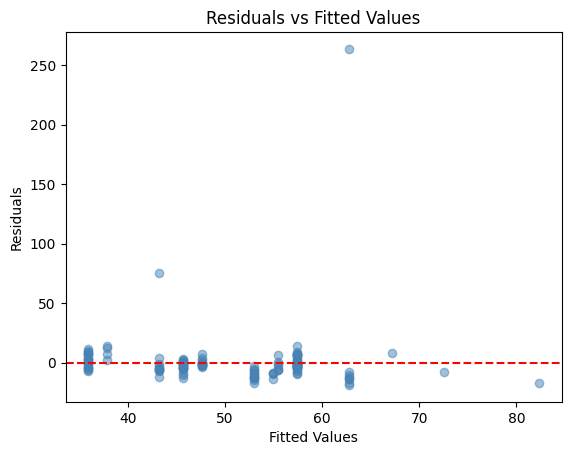

In [ ]:
plt.scatter(dfm["fitted"], dfm["residual"], alpha=0.5, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

question 11b

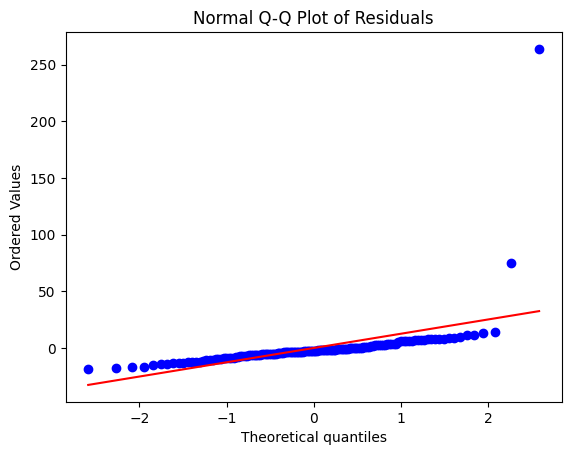

In [ ]:
scipy.stats.probplot(dfm["residual"], dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

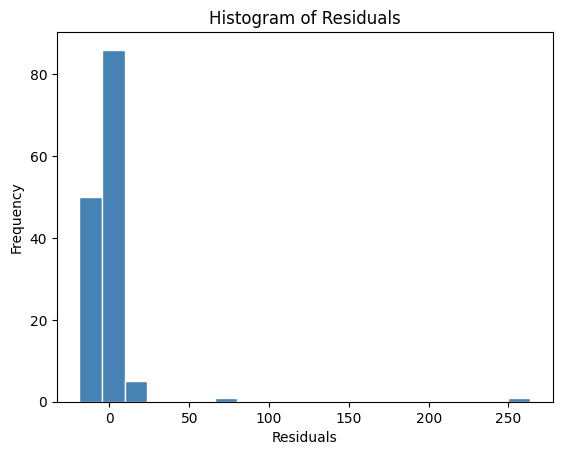

In [ ]:
plt.hist(dfm["residual"], bins=20, color="steelblue", edgecolor="white")
plt.xlabel("Residuals"); plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

normality assumption is violated because the histogram is very right-skewed with most residuals near zero. the q-q plot shows this because most of the data is relatively normal but there is one listing for $326.51 which breaks normality by itself since it is so far above what any normal distribution would predict.

the 326.51 listing has a residual of +263.74 which is completely unlike any other listing in the dataset. the 118.50 listing also has a residual of +75.30 but it is much less extreme than the other unusually large listing.

question 11c

In [ ]:
influence = model.get_influence()
summary_frame = influence.summary_frame()


In [ ]:
dfm["leverage"] = summary_frame["hat_diag"]
dfm["cooks_d"]  = summary_frame["cooks_d"]

In [ ]:
n = len(dfm)
k = 3

In [ ]:
leverage_threshold = 2 * (k + 1) / n
cooks_threshold    = 4 / n

In [ ]:
leverage_threshold

0.055944055944055944

In [ ]:
cooks_threshold

0.027972027972027972

high leverage points:
2,40,68,72,83,124

high influence points:
19,64

leverage only looks at the x-variables which in this case are wheels, cond and stock_photo, it just asks if the combination is unusual compared to the rest of the results.

influence is about what happens to the model if you take away the observation, which is why 19 is so impactful because its wheels count is normal but its price is so large that it hugely affects the fitted line.